[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Train class distribution after augmentation: Counter({1: 1925, 0: 1920})
Test class distribution: Counter({0: 397, 1: 345})
Using device: cuda


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

{'loss': 0.6046, 'grad_norm': 12.825169563293457, 'learning_rate': 1.8539584934665645e-05, 'epoch': 1.0}
{'eval_loss': 0.5055672526359558, 'eval_accuracy': 0.7601078167115903, 'eval_precision': 0.7287671232876712, 'eval_recall': 0.7710144927536232, 'eval_f1': 0.7492957746478873, 'eval_runtime': 1.9482, 'eval_samples_per_second': 380.865, 'eval_steps_per_second': 24.125, 'epoch': 1.0}
{'loss': 0.3559, 'grad_norm': 3.663555860519409, 'learning_rate': 1.4834742505764796e-05, 'epoch': 2.0}
{'eval_loss': 0.5821186304092407, 'eval_accuracy': 0.7547169811320755, 'eval_precision': 0.7404129793510325, 'eval_recall': 0.7275362318840579, 'eval_f1': 0.7339181286549707, 'eval_runtime': 2.0401, 'eval_samples_per_second': 363.712, 'eval_steps_per_second': 23.038, 'epoch': 2.0}
{'loss': 0.1734, 'grad_norm': 0.8570151925086975, 'learning_rate': 1.112990007686395e-05, 'epoch': 3.0}
{'eval_loss': 0.8119006752967834, 'eval_accuracy': 0.7628032345013477, 'eval_precision': 0.7770491803278688, 'eval_recall':

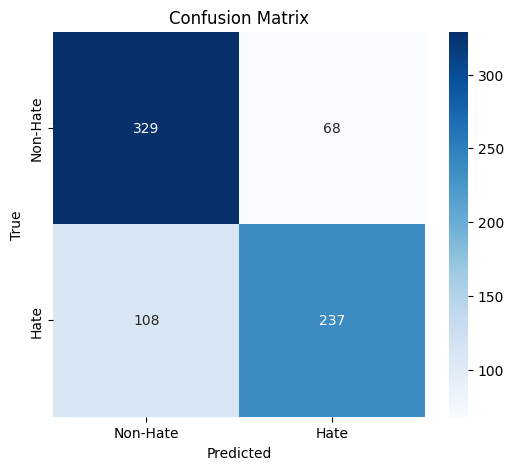

In [ ]:
# ================ CLEAN SETUP ================
import os, random, warnings, logging, re
os.environ["WANDB_DISABLED"] = "true"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# ================ IMPORTS ================
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset
from torch.nn import CrossEntropyLoss

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")
from nltk.corpus import wordnet, stopwords

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# ================ REPRODUCIBILITY ================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ================ TEXT CLEANING ================
STOPWORDS = set(stopwords.words("english"))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)    # remove URLs
    text = re.sub(r"@\w+", " ", text)       # remove mentions
    text = re.sub(r"#", " ", text)          # remove hash symbol
    text = re.sub(r"[^a-z0-9\s']", " ", text) # keep contractions/apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ================ SIMPLE AUGMENTATIONS ================
def get_synonyms(word):
    syns = set()
    for s in wordnet.synsets(word):
        for l in s.lemmas():
            w = l.name().replace("_", " ").lower()
            if w != word:
                syns.add(w)
    return list(syns)

def synonym_replacement(sentence, n=1):
    words = sentence.split()
    if len(words) == 0:
        return sentence
    candidates = [w for w in words if w not in STOPWORDS and len(get_synonyms(w))>0]
    random.shuffle(candidates)
    num_replaced = 0
    new_words = words.copy()
    for w in candidates:
        syns = get_synonyms(w)
        if not syns:
            continue
        replacement = random.choice(syns)
        new_words = [replacement if x==w else x for x in new_words]
        num_replaced += 1
        if num_replaced >= n:
            break
    return " ".join(new_words)

def random_deletion(sentence, p=0.1):
    words = sentence.split()
    if len(words) == 1:
        return sentence
    new_words = [w for w in words if random.uniform(0,1) > p]
    if len(new_words) == 0:
        return random.choice(words)
    return " ".join(new_words)

def augment_once(text):
    # combine small augmentations for diversity
    if random.random() < 0.5:
        return synonym_replacement(text, n=1)
    else:
        return random_deletion(text, p=0.1)

# ================ LOAD & PREPARE DATA ================
# Replace filename with your CSV path. CSV must contain "text" and "label".
DATA_PATH = "dataset_1_2.csv"   # <- change if needed
df = pd.read_csv(DATA_PATH)

# Map string labels to ints if needed
if df["label"].dtype == object:
    mapping = {"Non-Hate": 0, "Hate": 1}
    # If labels are "0"/"1" strings, astype(int) will handle; try mapping first
    try:
        df["label"] = df["label"].map(mapping).fillna(df["label"]).astype(int)
    except Exception:
        df["label"] = df["label"].astype(int)

# Clean text
df["text"] = df["text"].apply(clean_text)

# Split to train/test (keep test untouched)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ================ BALANCE VIA AUGMENTATION ================
# Target: oversample minority class by augmenting samples until class counts are balanced.
def augment_to_balance(df_train, max_aug_per_sample=3):
    counts = Counter(df_train["label"].tolist())
    majority = max(counts.values())
    rows = []
    for label in counts:
        current = counts[label]
        need = majority - current
        if need <= 0:
            continue
        samples_of_label = df_train[df_train["label"]==label]
        # sample with replacement to generate needed augmented rows
        for _ in range(need):
            sample = samples_of_label.sample(n=1, replace=True, random_state=random.randint(0,100000)).iloc[0]
            aug_text = augment_once(sample["text"])
            rows.append({"text": aug_text, "label": label})
    if rows:
        df_aug = pd.DataFrame(rows)
        df_new = pd.concat([df_train, df_aug]).reset_index(drop=True)
    else:
        df_new = df_train
    return df_new

# Apply augmentation balancing
train_df_balanced = augment_to_balance(train_df)

# You may optionally augment entire training set by adding extra augmented copies (small probability)
extra_aug_rows = []
aug_prob = 0.2  # augment additional 20% of train samples to add variety
for _, r in train_df_balanced.iterrows():
    if random.random() < aug_prob:
        extra_aug_rows.append({"text": augment_once(r["text"]), "label": r["label"]})
if extra_aug_rows:
    train_df_balanced = pd.concat([train_df_balanced, pd.DataFrame(extra_aug_rows)]).reset_index(drop=True)

print("Train class distribution after augmentation:", Counter(train_df_balanced["label"].tolist()))
print("Test class distribution:", Counter(test_df["label"].tolist()))

# ================ CLASS WEIGHTS ================
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df_balanced["label"].tolist()),
    y=train_df_balanced["label"].tolist()
)
# device set later
class_weights = torch.tensor(class_weights_np, dtype=torch.float)

# ================ TOKENIZER & DATASET ================
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

MAX_LEN = 192

class TextDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=tokenizer, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k,v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

train_dataset = TextDataset(train_df_balanced["text"].tolist(), train_df_balanced["label"].tolist(), tokenizer=tokenizer)
test_dataset  = TextDataset(test_df["text"].tolist(), test_df["label"].tolist(), tokenizer=tokenizer)

# ================ DEVICE & MOVE CLASS WEIGHTS ================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
class_weights = class_weights.to(device)

# ================ MODEL ================
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

# ================ CUSTOM TRAINER (weighted loss) ================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# ================ TRAINING ARGUMENTS ================
per_device_batch = 16
# If GPU available, use fp16 to speed/regularize; if GPU mem limited, reduce per_device_batch and add gradient_accumulation_steps
fp16_flag = True if torch.cuda.is_available() else False

training_args = TrainingArguments(
    output_dir="./results_bert",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=per_device_batch,
    per_device_eval_batch_size=per_device_batch,
    gradient_accumulation_steps=1,
    num_train_epochs=6,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    fp16=fp16_flag,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ================ METRICS ================
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    # for binary we're returning p/r/f1 for class '1' (Hate)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

# ================ TRAINER ================
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# ================ TRAIN ================
train_result = trainer.train()
trainer.save_model()  # save the best model

# ================ EVALUATE ================
pred_out = trainer.predict(test_dataset)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = test_df["label"].tolist()

print("\n✅ Test Accuracy:", accuracy_score(y_true, y_pred))
print("\n✅ Classification Report:\n", classification_report(y_true, y_pred, target_names=["Non-Hate","Hate"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Hate","Hate"], yticklabels=["Non-Hate","Hate"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()